# M1a: FM100's own cross-session reliability

`PLANssvep_bh_fm100.md` M1: before leaning on any FM100 feature as a
severity/type measure for the cross-modality work, check whether it's
even consistent session-to-session -- the exact check `ssvepBeh/` skipped
until after finding a promising-looking correlation that didn't hold up
(`docs/ssvepbeh_reliability_gaps.md`).

Four features, two kinds of reliability statistic: `TES`, `VKS_MajRad`,
`VKS_MinRad` are non-negative magnitudes (ICC(A,1), same method
`ssveps/`'s own M5 uses); `VKS_Angle` is periodic (a fitted ellipse axis
has no direction) so it uses a circular-circular correlation
(`circ_axial` + `circ_corrcc`) between session 1 and session 2 instead --
a linear ICC would silently give a wrong answer near the 0/180 wrap
point.

In [1]:
import sys
sys.path.append('../scripts')

import fm100_features

# fm100_features's own import inserts ssveps/scripts at sys.path[0] (it
# needs ssveps' reliability.py) -- ssveps/scripts has its own plotting.py
# too, so re-assert this project's scripts/ first before resolving
# "plotting", or it would silently import ssveps' version instead.
sys.path.insert(0, '../scripts')
import plotting

fm100_df = fm100_features.fm100_loader.load_fm100_raw()

pooled = fm100_features.subject_pooled_features(fm100_df)
print(f"{len(pooled)} subjects, {(pooled['n_sessions'] > 1).sum()} with more than one FM100 session")

48 subjects, 20 with more than one FM100 session


## Reliability table

In [2]:
reliability = fm100_features.reliability_table(fm100_df)
reliability

,feature,n,statistic,value,p_value
0,TES,19,icc,0.922598,3.447103e-09
1,VKS_MajRad,19,icc,0.843444,1.430067e-06
2,VKS_MinRad,19,icc,0.933059,4.446521e-10
3,VKS_Angle,19,circ_r,0.440840,1.479826e-01


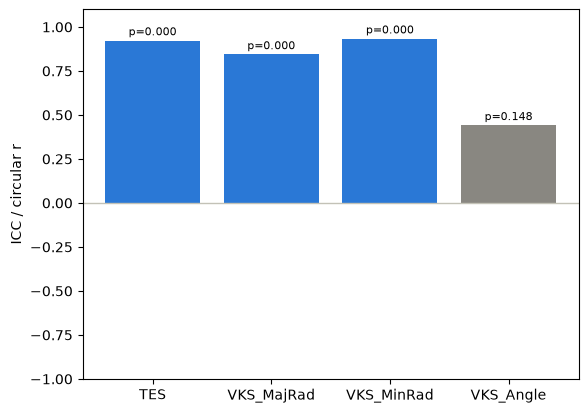

In [3]:
plotting.plot_reliability_table(reliability);

**The three magnitude features are highly reliable** -- TES (ICC=0.92),
VKS_MinRad (ICC=0.93), and VKS_MajRad (ICC=0.84) all clear the bar M9 used
for the EEG measures (ICC>0.8 was "reliable enough to build on" there).
**`VKS_Angle` is not** -- circular r=0.44, p=0.15, not significant at
n=19 paired subjects. A person's confusion-ellipse *direction* isn't
consistent test-to-retest the way its *magnitude* is.

This matters directly for interpreting the type/axis test in
`02_fm100_vs_behavioral.ipynb`: a significant `VKS_Angle` correlation
there would be a real finding riding on a noisier measurement than the
severity features enjoy -- worth remembering, not a reason to skip the
test (M9's own EEG work found real signal on `ramp_slope_red` despite it
being less reliable than `gain`).

## A closer look: per-subject session agreement

Scatter of each feature's session 1 vs. session 2 value, to see *how*
`VKS_Angle`'s unreliability shows up (outliers vs. uniformly noisy) rather
than just its summary statistic.

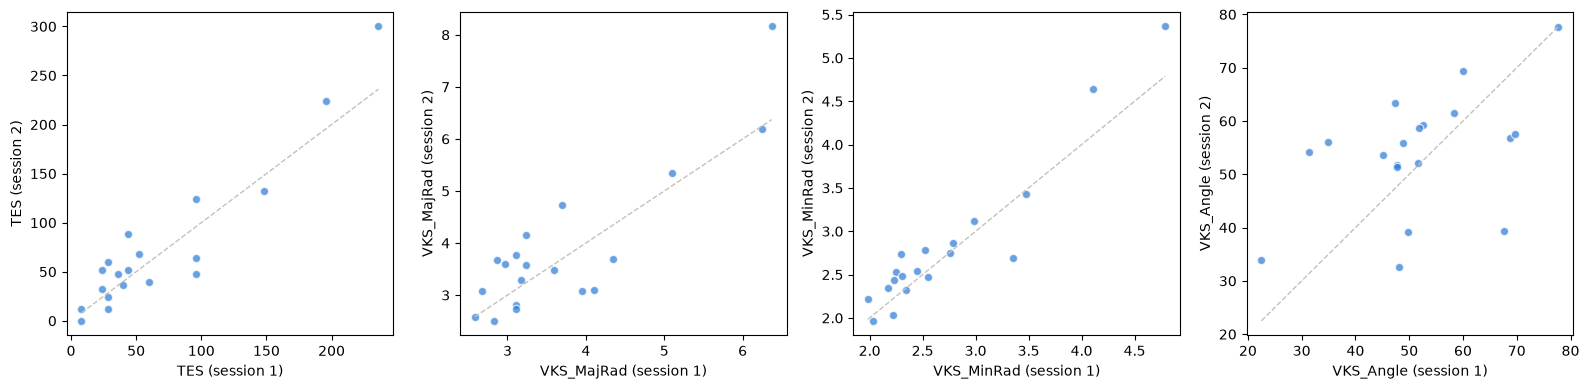

In [4]:
import matplotlib.pyplot as plt

paired = fm100_features.paired_sessions(fm100_df)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feature in zip(axes, ['TES', 'VKS_MajRad', 'VKS_MinRad', 'VKS_Angle']):
    ax.scatter(paired[f'{feature}_session1'], paired[f'{feature}_session2'], color='#2a78d6', alpha=0.7, edgecolor='white')
    lims = [paired[f'{feature}_session1'].min(), paired[f'{feature}_session1'].max()]
    ax.plot(lims, lims, color='#c3c2b7', linewidth=1, linestyle='--')
    ax.set_xlabel(f'{feature} (session 1)')
    ax.set_ylabel(f'{feature} (session 2)')
fig.tight_layout()

`VKS_Angle`'s session 1 vs. session 2 points scatter broadly around the
identity line rather than hugging it the way the three magnitude features
do -- consistent with the summary statistic, not a single outlier driving
the low reliability.

## Verdict for M1b

Proceed to `02_fm100_vs_behavioral.ipynb` with all four features, but
carry `VKS_Angle`'s reliability caveat forward explicitly wherever it's
used -- a real but noisier signal, not a solid one.